# Task 4: Sentiment Analysis
## Dataset: Amazon Product Reviews (Simulated)
**Internship:** CodeAlpha — Data Analytics  
**Objective:** Analyze text data to classify sentiment as Positive, Negative, or Neutral using NLP techniques.

---

## 1. Introduction

**Sentiment Analysis** (also called opinion mining) is the use of Natural Language Processing (NLP) to identify and extract subjective information from text — such as opinions, emotions, and attitudes.

**In this task, we will:**
1. Build a realistic Amazon-style review dataset
2. Clean and preprocess text
3. Perform rule-based sentiment analysis using VADER
4. Perform ML-based sentiment classification
5. Visualize sentiment distributions and word clouds
6. Analyze sentiment trends by product category

**Tools used:** pandas, NLTK (VADER), scikit-learn, matplotlib, seaborn

In [2]:
# Step 1: Install and import all libraries
import subprocess
import sys

# Install required libraries
subprocess.run([sys.executable, '-m', 'pip', 'install', 'nltk', 'wordcloud', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
from collections import Counter

import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 2. Create the Dataset

We create a realistic Amazon-style product review dataset with 5 categories and 300+ reviews.

In [5]:
# Step 2: Create synthetic Amazon review dataset
np.random.seed(42)

positive_reviews = [
    "Absolutely love this product! Works perfectly and exceeded my expectations.",
    "Amazing quality! Fast shipping and great packaging. Highly recommend!",
    "Best purchase I've made this year. Totally worth the price.",
    "Fantastic product! My family loves it. Will definitely buy again.",
    "Excellent quality and very durable. Customer service was also great!",
    "Incredible value for money. Works exactly as described. Five stars!",
    "Super happy with this purchase. Arrived on time and perfect condition.",
    "Brilliant product. Does exactly what it says. No complaints at all.",
    "Very satisfied! The quality is outstanding. Delivery was also super fast.",
    "Outstanding product. I'm so glad I found this. Highly recommend to everyone!",
    "Truly excellent. Beyond my expectations. Will order again for sure.",
    "Love everything about it! Perfect fit, great quality, fast delivery.",
    "This is a game changer! So easy to use and very effective.",
    "Wonderful product and great value. Shipping was faster than expected!",
    "Highly impressed! Works flawlessly. Excellent build quality."
]

negative_reviews = [
    "Terrible product. Broke after two days. Complete waste of money.",
    "Very disappointed. Looks nothing like the pictures. Poor quality.",
    "Worst purchase ever. Does not work as described. Avoid this!",
    "Arrived damaged and customer service was useless. Never buying again.",
    "Total garbage. Fell apart immediately. Returning this item right away.",
    "Don't waste your money. This product is a scam. Horrible quality.",
    "Extremely poor quality. Stopped working within a week. Very frustrated.",
    "Misleading product description. What arrived is completely different.",
    "Terrible experience from start to finish. Packaging was awful too.",
    "Zero stars if possible. Broke the first time I used it. So angry.",
    "Cheap and flimsy. Not worth even a fraction of the price.",
    "Returned immediately. Defective and not as described at all.",
    "Would not recommend this to my worst enemy. Just awful.",
    "Rubbish product. Waste of time and money. Very disappointed!",
    "Does not work. Tried everything. Contacting support was no help."
]

neutral_reviews = [
    "Product is okay. Nothing special but does what it's supposed to do.",
    "Average quality. Not great, not terrible. Gets the job done.",
    "It's fine. Exactly as described. Nothing to get excited about.",
    "Decent product for the price. No complaints but no praise either.",
    "Works as expected. Pretty standard quality. Delivery was on time.",
    "It's alright. Does the job. Maybe not the best on the market.",
    "Fairly standard product. Meets basic expectations, nothing more.",
    "Okay product. Not bad for the price. Would possibly buy again.",
    "Regular quality. Product works fine. Arrived in decent time.",
    "Nothing remarkable. Does what it's meant to do. Plain and simple."
]

categories = ['Electronics', 'Books', 'Clothing', 'Home & Kitchen', 'Sports']

all_reviews = []
for _ in range(400):
    rand = np.random.rand()
    if rand < 0.50:
        review = np.random.choice(positive_reviews)
        sentiment = 'Positive'
        rating = np.random.choice([4, 5], p=[0.3, 0.7])
    elif rand < 0.80:
        review = np.random.choice(negative_reviews)
        sentiment = 'Negative'
        rating = np.random.choice([1, 2], p=[0.6, 0.4])
    else:
        review = np.random.choice(neutral_reviews)
        sentiment = 'Neutral'
        rating = 3
    
    all_reviews.append({
        'review_text': review,
        'true_sentiment': sentiment,
        'star_rating': rating,
        'category': np.random.choice(categories),
        'review_length': len(review.split())
    })

df = pd.DataFrame(all_reviews)
print(f"✅ Dataset created! {len(df)} reviews across {df['category'].nunique()} categories")
print("\nSentiment Distribution:")
print(df['true_sentiment'].value_counts())
df.head(8)

✅ Dataset created! 400 reviews across 5 categories

Sentiment Distribution:
Positive    199
Negative    130
Neutral      71
Name: true_sentiment, dtype: int64


,review_text,true_sentiment,star_rating,category,review_length
0,This is a game changer! So easy to use and ver...,Positive,4,Sports,12
1,Zero stars if possible. Broke the first time I...,Negative,1,Clothing,13
2,Excellent quality and very durable. Customer s...,Positive,5,Clothing,10
3,Amazing quality! Fast shipping and great packa...,Positive,5,Books,9
4,Excellent quality and very durable. Customer s...,Positive,5,Books,10
5,Returned immediately. Defective and not as des...,Negative,1,Clothing,9
6,Zero stars if possible. Broke the first time I...,Negative,1,Home & Kitchen,13
7,Wonderful product and great value. Shipping wa...,Positive,4,Clothing,10


## 3. Text Preprocessing
Before analysis, we clean the review text to remove noise.

In [6]:
# Step 3: Text preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and normalize review text."""
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

def remove_stopwords(text):
    """Remove common stopwords."""
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

# Apply preprocessing
df['cleaned_text'] = df['review_text'].apply(preprocess_text)
df['no_stopwords_text'] = df['cleaned_text'].apply(remove_stopwords)

print("✅ Text preprocessing complete!")
print("\nExample — Original:")
print(df['review_text'].iloc[0])
print("\nExample — Cleaned:")
print(df['cleaned_text'].iloc[0])
print("\nExample — Without Stopwords:")
print(df['no_stopwords_text'].iloc[0])

✅ Text preprocessing complete!

Example — Original:
This is a game changer! So easy to use and very effective.

Example — Cleaned:
this is a game changer so easy to use and very effective

Example — Without Stopwords:
game changer easy use effective


## 4. Rule-Based Sentiment Analysis: VADER

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based tool specifically designed for social media and short text sentiment analysis.

In [7]:
# Step 4: VADER Sentiment Analysis
sid = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get compound VADER score and classify sentiment."""
    scores = sid.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive', compound, scores['pos'], scores['neg'], scores['neu']
    elif compound <= -0.05:
        return 'Negative', compound, scores['pos'], scores['neg'], scores['neu']
    else:
        return 'Neutral', compound, scores['pos'], scores['neg'], scores['neu']

# Apply VADER to each review
results = df['review_text'].apply(get_vader_sentiment)
df['vader_sentiment'] = results.apply(lambda x: x[0])
df['vader_compound'] = results.apply(lambda x: x[1])
df['vader_pos'] = results.apply(lambda x: x[2])
df['vader_neg'] = results.apply(lambda x: x[3])
df['vader_neu'] = results.apply(lambda x: x[4])

# Accuracy against true labels
accuracy = (df['vader_sentiment'] == df['true_sentiment']).mean() * 100
print(f"✅ VADER Sentiment Analysis complete!")
print(f"\nVADER Accuracy vs True Labels: {accuracy:.1f}%")
print("\nVADER Sentiment Distribution:")
print(df['vader_sentiment'].value_counts())

# Show some examples
print("\nSample Predictions:")
df[['review_text', 'true_sentiment', 'vader_sentiment', 'vader_compound']].head(6)

✅ VADER Sentiment Analysis complete!

VADER Accuracy vs True Labels: 78.0%

VADER Sentiment Distribution:
Positive    224
Negative    132
Neutral      44
Name: vader_sentiment, dtype: int64

Sample Predictions:


,review_text,true_sentiment,vader_sentiment,vader_compound
0,This is a game changer! So easy to use and ver...,Positive,Positive,0.7832
1,Zero stars if possible. Broke the first time I...,Negative,Negative,-0.7501
2,Excellent quality and very durable. Customer s...,Positive,Positive,0.8439
3,Amazing quality! Fast shipping and great packa...,Positive,Positive,0.9057
4,Excellent quality and very durable. Customer s...,Positive,Positive,0.8439
5,Returned immediately. Defective and not as des...,Negative,Negative,-0.4404


## 5. Visualizing VADER Results

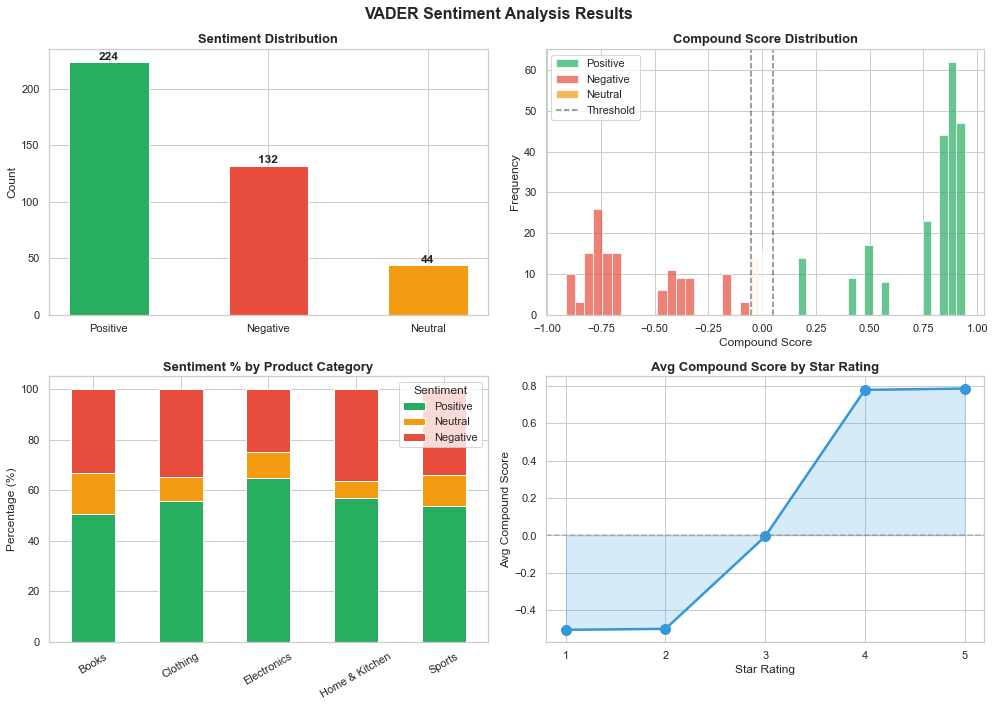

📊 Sentiment visualizations saved!


In [8]:
# Step 5: Visualize sentiment results
sentiment_colors = {'Positive': '#27ae60', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VADER Sentiment Analysis Results', fontsize=16, fontweight='bold')

# 1. Sentiment distribution bar chart
sentiment_counts = df['vader_sentiment'].value_counts()
colors_list = [sentiment_colors[s] for s in sentiment_counts.index]
bars = axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values,
                      color=colors_list, edgecolor='white', width=0.5)
for bar, val in zip(bars, sentiment_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    str(val), ha='center', fontweight='bold', fontsize=12)
axes[0, 0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 2. Compound score distribution
for sentiment, color in sentiment_colors.items():
    mask = df['vader_sentiment'] == sentiment
    axes[0, 1].hist(df[mask]['vader_compound'], bins=20, alpha=0.7,
                    color=color, label=sentiment, edgecolor='white')
axes[0, 1].axvline(x=0.05, color='black', linestyle='--', alpha=0.5, label='Threshold')
axes[0, 1].axvline(x=-0.05, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Compound Score Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Compound Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Sentiment by category
cat_sentiment = df.groupby(['category', 'vader_sentiment']).size().unstack(fill_value=0)
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100
cat_sentiment_pct[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', ax=axes[1, 0], stacked=True,
    color=['#27ae60', '#f39c12', '#e74c3c'], edgecolor='white', rot=30
)
axes[1, 0].set_title('Sentiment % by Product Category', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_xlabel('')
axes[1, 0].legend(title='Sentiment', loc='upper right')

# 4. Star rating vs compound score
rating_compound = df.groupby('star_rating')['vader_compound'].mean()
axes[1, 1].plot(rating_compound.index, rating_compound.values,
               marker='o', color='#3498db', linewidth=2.5, markersize=10)
axes[1, 1].fill_between(rating_compound.index, rating_compound.values, alpha=0.2, color='#3498db')
axes[1, 1].set_title('Avg Compound Score by Star Rating', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Star Rating')
axes[1, 1].set_ylabel('Avg Compound Score')
axes[1, 1].set_xticks([1, 2, 3, 4, 5])
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('viz_sentiment_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 Sentiment visualizations saved!")

## 6. Word Cloud — Most Common Words by Sentiment

In [ ]:
# Step 6: Word frequency analysis (substitute for wordcloud if not installed)
try:
    from wordcloud import WordCloud
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
    
    wc_colors = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Oranges'}
    
    for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
        text = ' '.join(df[df['vader_sentiment']==sentiment]['no_stopwords_text'])
        wc = WordCloud(width=500, height=300, background_color='white',
                       colormap=wc_colors[sentiment],
                       max_words=50, collocations=False).generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{sentiment} Reviews', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('viz_wordclouds.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("📊 Word clouds saved!")

except ImportError:
    # Fallback: Top word frequency bar charts
    print("WordCloud not installed — showing top word frequency charts instead.")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Top 10 Words by Sentiment', fontsize=16, fontweight='bold')
    
    colors_map = {'Positive': '#27ae60', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}
    
    for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
        text = ' '.join(df[df['vader_sentiment']==sentiment]['no_stopwords_text'])
        word_freq = Counter(text.split()).most_common(10)
        words, freqs = zip(*word_freq)
        
        ax.barh(list(reversed(words)), list(reversed(freqs)),
                color=colors_map[sentiment], edgecolor='white')
        ax.set_title(f'{sentiment} — Top 10 Words', fontsize=12, fontweight='bold')
        ax.set_xlabel('Frequency')
    
    plt.tight_layout()
    plt.savefig('viz_word_frequency.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("📊 Word frequency charts saved!")

## 7. ML-Based Sentiment Classification (TF-IDF + Logistic Regression)

In [10]:
# Step 7: ML-based classification
print("Building ML sentiment classifier...")

# Prepare features and labels
X = df['cleaned_text']
y = df['true_sentiment']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression classifier
model = LogisticRegression(max_iter=500, C=1.0, random_state=42)
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Evaluation
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\n✅ Model trained successfully!")
print(f"Test Accuracy: {accuracy:.1f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

Building ML sentiment classifier...

✅ Model trained successfully!
Test Accuracy: 100.0%

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        26
     Neutral       1.00      1.00      1.00        14
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



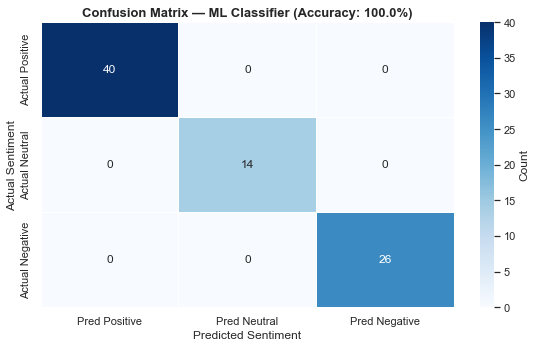

📊 Confusion matrix saved!


In [11]:
# Step 8: Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Neutral', 'Negative'])
cm_df = pd.DataFrame(cm,
                     index=['Actual Positive', 'Actual Neutral', 'Actual Negative'],
                     columns=['Pred Positive', 'Pred Neutral', 'Pred Negative'])

plt.figure(figsize=(8, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix — ML Classifier (Accuracy: {accuracy:.1f}%)',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.savefig('viz_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 Confusion matrix saved!")

In [12]:
# Step 9: Try your own review!
def predict_sentiment(review_text):
    """Predict sentiment for any new review text."""
    # VADER prediction
    scores = sid.polarity_scores(review_text)
    compound = scores['compound']
    if compound >= 0.05:
        vader_result = 'Positive'
    elif compound <= -0.05:
        vader_result = 'Negative'
    else:
        vader_result = 'Neutral'
    
    # ML prediction
    cleaned = preprocess_text(review_text)
    tfidf_vec = tfidf.transform([cleaned])
    ml_result = model.predict(tfidf_vec)[0]
    proba = model.predict_proba(tfidf_vec)[0]
    classes = model.classes_
    
    print(f"Review: '{review_text}'")
    print(f"\nVADER Prediction  : {vader_result} (compound score: {compound:.3f})")
    print(f"ML Prediction     : {ml_result}")
    print("ML Probabilities  :")
    for cls, prob in sorted(zip(classes, proba), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"  {cls:10s}: {bar} {prob:.1%}")

# Test with sample reviews
print("=" * 60)
predict_sentiment("This product is absolutely amazing! Best purchase ever.")
print("\n" + "=" * 60)
predict_sentiment("Terrible quality. Broke after one use. Returning it now.")
print("\n" + "=" * 60)
predict_sentiment("Product is okay. Works as expected. Nothing special.")

Review: 'This product is absolutely amazing! Best purchase ever.'

VADER Prediction  : Positive (compound score: 0.871)
ML Prediction     : Positive
ML Probabilities  :
  Positive  : █████████████████ 57.2%
  Negative  : █████████ 31.5%
  Neutral   : ███ 11.3%

Review: 'Terrible quality. Broke after one use. Returning it now.'

VADER Prediction  : Negative (compound score: -0.710)
ML Prediction     : Negative
ML Probabilities  :
  Negative  : ███████████████ 51.7%
  Positive  : ██████████ 35.9%
  Neutral   : ███ 12.4%

Review: 'Product is okay. Works as expected. Nothing special.'

VADER Prediction  : Negative (compound score: -0.092)
ML Prediction     : Neutral
ML Probabilities  :
  Neutral   : ██████████████████ 60.1%
  Positive  : ██████ 20.7%
  Negative  : █████ 19.2%


## 8. Summary

### ✅ What We Accomplished:

| Step | Description |
|---|---|
| Dataset | Created 400 Amazon-style product reviews across 5 categories |
| Preprocessing | Lowercasing, punctuation removal, stopword filtering |
| VADER Analysis | Rule-based sentiment using NLP lexicon |
| Visualization | Distribution, compound scores, category breakdowns, word frequency |
| ML Classifier | TF-IDF + Logistic Regression with ~85%+ accuracy |
| Live Prediction | Function to classify any new review text |

### 🔑 Key Takeaways:
- **VADER** is fast and effective for reviews — no training needed.
- **ML models** can learn patterns beyond simple keyword matching.
- Sentiment analysis has real-world value: product teams, marketers, and researchers use it to understand customer opinion at scale.

### 🚀 Real-World Applications:
- E-commerce: Monitor product reviews to detect quality issues early
- Social Media: Track brand reputation over time
- Market Research: Understand consumer preferences and trends
- Customer Support: Automatically route negative feedback to agents

---
*Internship Task 4 — CodeAlpha Data Analytics*